# Numerical solution of differential equations - initial value problem

In [1]:
import numpy as np
from ipywidgets import interact
import matplotlib.pyplot as plt
%matplotlib inline
import sympy as sym
sym.init_printing()

## Introduction


### Writing (a single) differential equation

Assume that a first-order differential equation can be written in *explicit* form:

$$y'=f(t, y),$$

where $f(t, y)$ is a given function and $y'=dy/dt$.

Additionally, an initial condition is given:

$$y(t_0)=y_0.$$

The goal of solving the differential equation is to compute the function $y(t)$ that solves the initial value problem defined above. Under certain conditions on the function $f(t, y)$, the initial value problem has a unique solution on an interval containing $t_0$.

In numerical solving we always compute a table of the function $y(t_i)$ that solves the given initial value problem. The nodes $t_i$ are usually equidistant:

$$t_0, t_0+h, t_0+2h,\dots$$

and we call $h$ the (time) step (of integration).

Here we will look at some numerical methods for solving differential equations with an initial condition.

## Euler's method

The **explicit Euler's method** is based on the Taylor series expansion of the function $y$:

$$y(t+h)=y(t)+f(t, y(t))\,h +
\mathcal{O}(h^2).$$

We make a method error of $\mathcal{O}(h^2)$ because we neglect the second and higher-order derivatives; now, given a known value $y(t)$ and the derivative $y'(t)=f(t,y)$, we can estimate the value at the next time step $t+h$. Once we know the values at $t+h$, we repeat the procedure!

Steps of Euler's method:

1. Set $i=0$, $t_0$, $y_0=y(t_0)$.
2. Compute the function value at $t_{i+1}=t_i+h$: $y_{i+1}= y_i + f(t_i, y_i)\,h.$
3. $i=i+1$ and continue at step 2.

We solve the differential equation on the interval $[t_0,t_n]$ and $h=(t_n-t_0)/n$. $n$ is the number of integration steps (how many times we perform step 2 in the algorithm above).

Numerical solution of the initial value problem:

$$y_0, y_1, y_2,\dots, y_{n}$$

at the values of the independent variable:

$$t_0, t_1, t_2\, \dots \, t_n.$$

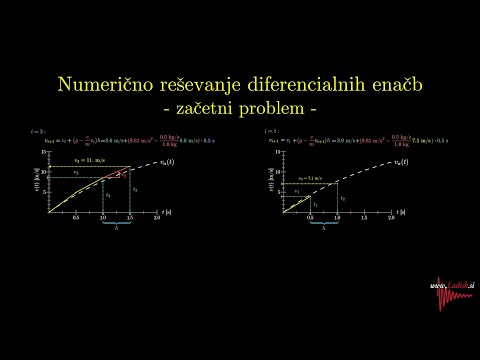

In [2]:
from IPython.display import YouTubeVideo
YouTubeVideo('cfZ8v0b-R8o', width=800, height=300)

### Error of Euler's method

The error of Euler's method at each step is of order $\mathcal{O}(h^2)$.

Since over the interval from $t_0$ to $t_n$ we make this error $n$ times, the cumulative error is $n\,\mathcal{O}(h^2)=\frac{t_n-t_0}{h}\,\mathcal{O}(h^2)=\mathcal{O}(h)$.

Locally the error is second order, but globally the error is first order, and because Euler's method is so inaccurate, we rarely use it in practice!

#### Error estimate

The exact solution $y(t_n)$ at step size $h$ is:

$$y(t_n)=y_{n,h}+E_h,$$

where $y_{n,h}$ is the numerical approximation and $E_h$ is the method error. Since the global error is first order, we can write the error as:

$$E_h=k\,h.$$

Similarly, for step size $2h$ we can write:

$$y(t_n)=y_{n,2h}+E_{2h},$$

where $y_{n,2h}$ is the numerical approximation and $E_{2h}$ is the method error:

$$E_{2h}=k\,2\,h.$$

Assuming that the constant $k$ is the same for step $h$ and step $2h$, we can determine the error estimate for the better approximation $E_h$. Clearly:

$$y_{n,h}+k\,h=y_{n,2h}+2\,k\,h$$

then we determine the *error estimate*:

$$E_h=k\,h=y_{n,h}-y_{n,2h}.$$

### A note on the implicit Euler's method

In the explicit Euler's method we compute the solution at $t_{i+1}$ from the computed value at $t_i$.

If the unknown value of the solution at $t_{i+1}$, that is $y_{i+1}$, appeared on the right-hand side as well, we would be talking about the **implicit Euler's method** (or *backward Euler's method*):

$$y_{i+1}=y_i+f(t_{i+1}, y_{i+1})\,h.$$

Because the sought value $y_{i+1}$ appears on both sides of the equation, to determine $y_{i+1}$ we must solve a (nonlinear) equation. The advantage of the implicit Euler's method is that it is more stable (e.g., for stiff systems, which we will learn about later) than the explicit form, but it is numerically more demanding (because of solving the equation).

### Numerical implementation

First we import the required libraries:

In [3]:
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline

Next let us define Euler's method:

In [4]:
def euler(f, t, y0, *args, **kwargs):
    """
    Euler's method for solving a system of differential equations: y' = f(t, y)

    :param f:  function returning the first derivative - f(t, y)
    :param t:  time vector where we compute the solution
    :param y0: initial value
    :param args: additional arguments of the function f (positional)
    :param kwargs: additional arguments of the function f (keyword)
    :return y: returns an np.array ``y`` of function values.
    """
    y = np.zeros_like(t)
    y[0] = y0
    h = t[1]-t[0]
    for i in range(len(t)-1):
        y[i+1] = y[i] + f(t[i], y[i], *args, **kwargs) * h
    return y

Let us prepare a function for the error estimate (in numerical terms it would be better to include the error estimate inside the `euler` function, but for clarity we present it separately):

In [5]:
def euler_error(f, t, y0, *args, **kwargs):
    """ Error estimate of Euler's method; the arguments are the same as for the `euler` function
    """
    n = len(t)
    if n < 5:
        raise Exception('There must be at least 5 nodes.')
    if n%2==0: # even number of nodes; remove one point and make it odd (so the number of subintervals is even)
        n = n - 1
    y_h = euler(f, t[:n], y0, *args, **kwargs)
    y_2h = euler(f, t[:n:2], y0, *args, **kwargs)
    E_h = y_h[-1] - y_2h[-1]
    return E_h

### Numerical example


As an example, let us solve the differential equation that describes a falling body subjected to gravity and air resistance:
![Falling body](./fig/padanje_telesa.png)

According to Newton's second law, we can write the differential equation:

$$m\,g-c\,v=m\,v',$$

where $m$ is the mass, $g$ the gravitational acceleration, $c$ the air-resistance coefficient, and $v$ the velocity. We would like to solve the differential equation subject to the initial condition:

$$v(0)=0\,\textrm{m/s}.$$

The right-hand side / first-derivative function $f(t,y)$ is:

$$f(t,y)=g-c\,
\frac{y}{m}$$

and the initial condition:

$$y_0=0.$$

Let us define the right-hand-side function:

In [6]:
def f_air_resistance(t, y, g=9.81, m=1., c=0.5):
    return g-c*y/m

Let us define the initial condition and the time vector where we want the result:

In [7]:
v0 = 0
t = np.linspace(0, 10, 11)
t

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

We call the `euler` function to compute the values of $y$ (velocity $v$):

In [8]:
y = euler(f_air_resistance, t, y0=v0)
y

array([ 0.        ,  9.81      , 14.715     , 17.1675    , 18.39375   ,
       19.006875  , 19.3134375 , 19.46671875, 19.54335938, 19.58167969,
       19.60083984])

We plot the result:

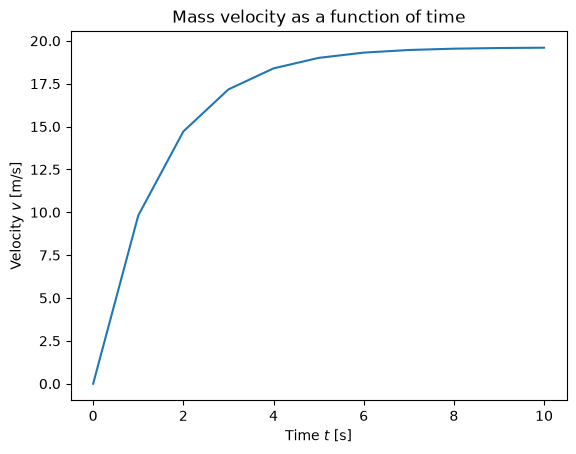

In [9]:
plt.plot(t, y)
plt.title('Mass velocity as a function of time')
plt.xlabel('Time $t$ [s]')
plt.ylabel('Velocity $v$ [m/s]')
plt.show()

Let us now check the effect of the time step:

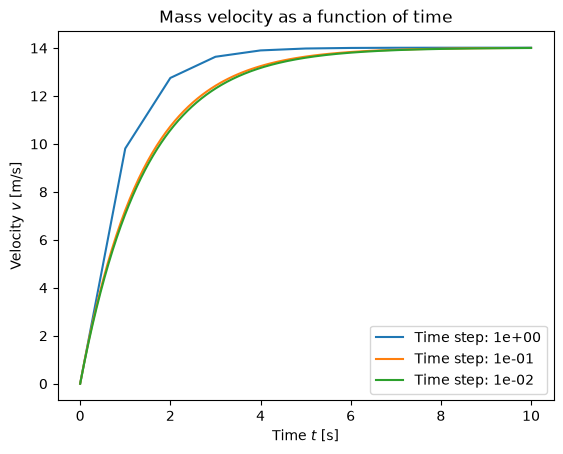

In [10]:
for n in [11, 101, 1001]:
    t = np.linspace(0, 10, n)
    y = euler(f_air_resistance, t, y0=v0, c=0.7)
    plt.plot(t, y, label=f'Time step: {t[1]:1.0e}')
plt.title('Mass velocity as a function of time')
plt.xlabel('Time $t$ [s]')
plt.ylabel('Velocity $v$ [m/s]')
plt.legend()
plt.show()

We observe that the numerical error decreases substantially when the step changes from 1 to 0.1!

Let us also estimate the error at 100 and 1000 subintervals:

In [11]:
n=101
t = np.linspace(0, 10, n)
euler_error(f_air_resistance, t, y0=v0)

In [12]:
n=1001
t = np.linspace(0, 10, n)
euler_error(f_air_resistance, t, y0=v0)

When we reduced the step to a tenth, the error decreased proportionally as well (first-order error).

Let us also look at the case where the air resistance `c` is an argument of the `euler` function and is passed via `**kwargs` to the `f_air_resistance()` function:

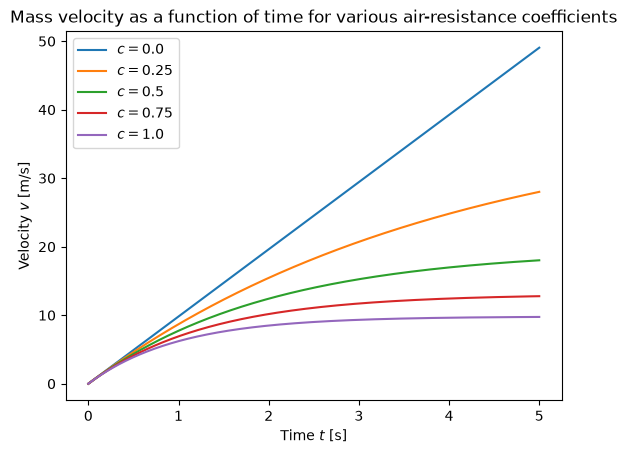

In [13]:
for c in np.linspace(0, 1, 5):
    t = np.linspace(0, 5, 1001)
    y = euler(f_air_resistance, t, y0=v0, c=c)
    plt.plot(t, y, label=f'$c={c}$')
plt.title('Mass velocity as a function of time for various air-resistance coefficients')
plt.xlabel('Time $t$ [s]')
plt.ylabel('Velocity $v$ [m/s]')
plt.legend()
plt.show()

## Second-order Runge–Kutta method

Euler's method is first order (the global error $\mathcal{O}(h)$ is indeed first order). If we wanted to derive a second-order-error method, we would need to use the Taylor series expansion of $y(t+h)$, where we neglect the third and higher derivatives:

$$y(t+h)=y(t)+y'(t)\,h + \frac{1}{2}y''(t)\,h^2+\mathcal{O}(h^3).$$

The local error of the method will thus be third order and the global error second order.

We use the substitutions $y'(t)=f(t,y)$ and $y''(t)=f'(t,y)$:

$$y(t+h)=y(t)+f(t,y)\,h + \frac{1}{2}f'(t,y)\,h^2+\mathcal{O}(h^3).$$

Because the right-hand side $f(t,y)$ depends on both the independent variable $t$ and the dependent variable $y$, we must use implicit differentiation:

$$f'(t,y)=\frac{\partial f(t,y)}{\partial t}+\frac{\partial f(t,y)}{\partial y}\,\underbrace{\frac{\textrm{d} y}{\textrm{d} t}}_{y'=f(t,y)}
=\frac{\partial f(t,y)}{\partial t}+\frac{\partial f(t,y)}{\partial y}\,{f(t, y)}.$$

We substitute into the Taylor series expression:

$$y(t+h)_{\textrm{Taylor}}=y(t+h)=y(t)+f(t,y)\,h + \frac{1}{2}\,{\LARGE(}
\frac{\partial f(t,y)}{\partial t}+\frac{\partial f(t,y)}{\partial y}\,{f(t, y)}
{\LARGE)}\,h^2.$$

As can be seen from the expression above, we need additional derivatives. This poses a certain difficulty that can be avoided in various ways; in what follows we will look at the *Runge–Kutta* approach. Because we will need the expression above later, we have named it here $y(t+h)_{\textrm{Taylor}}$.

### Idea of the Runge–Kutta approach

The dilemma above is resolved by the *Runge–Kutta* method (developed in 1901) with an idea we have already encountered in Gaussian integration: it tries to find a more accurate solution with a weighted additional value of the function $f$:

$$y(t+h)_{\textrm{Runge-Kutta}}=y(t)+c_0\,f\left(t,y\right)\,h +c_1
\underbrace{f{\large(}t+p\,h,y+q\,h\,f(t,y){\large)}}_{A}\,h.$$

where $c_0$, $c_1$, $p$, and $q$ are unknown constants (in principle from 0 up to and including 1). If we used $c_1=0$ in the expression above, we would derive a first-order method; but with an additional function value ($A$) it will turn out that we derive a second-order method.

We continue the search for the unknown constants $c_0$, $c_1$, $p$, $q$ by writing $A$ in the form of a first-order Taylor series:

$$f{\large(}t+p\,h,y+q\,h\,f(t,y){\large)}=
\underbrace{
f{\large(}t,y{\large)}+
\frac{\partial f(t,y)}{\partial t}\,\left(p\,h\right)+
\frac{\partial f(t,y)}{\partial y}\,\left(q\,h\,f(t, y)\right)
}_{B}.$$

Now we substitute the derived $B$ back into the expression for $y(t+h)_{\textrm{Runge-Kutta}}$:

$$y(t+h)_{\textrm{Runge-Kutta}}=y(t)+c_0\,f\left(t,y\right)\,h +c_1
{\LARGE(}
f{\large(}t,y{\large)}+
\frac{\partial f(t,y)}{\partial t}\,\left(p\,h\right)+
\frac{\partial f(t,y)}{\partial y}\,\left(q\,h\,f(t, y)\right)
{\LARGE)}
\,h.$$

We continue the derivation and rearrange the equation so that it resembles the one derived above with the Taylor series $y(t+h)_{\textrm{Taylor}}$:

$$y(t+h)_{\textrm{Runge-Kutta}}=y(t)+(c_0+c_1)\,f\left(t,y\right)\,h +\frac{1}{2}
{\LARGE(}
\frac{\partial f(t,y)}{\partial t}\,2\,c_1\,p+
2\,c_1\,q\,\frac{\partial f(t,y)}{\partial y}\,f(t, y)
{\LARGE)}
\,h^2.$$

Now let us compare with the expression derived above:

$$y(t+h)_{\textrm{Taylor}}=y(t)+f(t,y)\,h + \frac{1}{2}\,{\LARGE(}
\frac{\partial f(t,y)}{\partial t}+\frac{\partial f(t,y)}{\partial y}\,{f(t, y)}
{\LARGE)}\,h^2.$$

We find that for equality to hold we must have:

$$c_0+c_1=1,\qquad 2\,c_1\,p=1,\qquad 2\,c_1\,q=1.$$

So we have three equations and four unknowns. We can therefore choose one of the constants arbitrarily and compute the other three. If, for example, we choose $c_0=0$, we would call this the *modified Euler's method* and the remaining parameters would be: $c_1=1$, $p=q=1/2$. The choice of parameters has no essential effect on the solution. It is worth noting, however, that even the second-order Runge–Kutta method is rarely used, since better methods exist.

We substitute the parameters $c_0$, $c_1$, $p$, and $q$ into the first equation of this section. Once the initial time $t_0$ and the initial condition $y_0$ are defined, we use the second-order Runge–Kutta method:

$$y_{i+1} = y_i + f\left(t_i+\frac{1}{2}\,h, y_i+\frac{1}{2}\,h\,f(t_i,y_i)\right)\,h.$$

## Fourth-order Runge–Kutta method

Similarly to how we derived the second-order Runge–Kutta method, the fourth-order Runge–Kutta method is derived. For the fourth-order method, too, there are several variants, and by the fourth-order Runge–Kutta method we mean the following method:

$$y_{i+1}=y_i+\frac{1}{6}(k_0+2\,k_1+2\,k_2+k_3),$$

where:

$$\begin{aligned}
k_0&=h\,f(t_i,y_i)\\
k_1&=h\,f\left(t_i+\frac{h}{2},y_i+\frac{k_0}{2}\right)\\
k_2&=h\,f\left(t_i+\frac{h}{2},y_i+\frac{k_1}{2}\right)\\
k_3&=h\,f\left(t_i+h,y_i+k_2\right).
\end{aligned}
$$

The steps of the fourth-order Runge–Kutta method are:

1. Set $i=0$ and $t_0$, $y_0=y(t_0)$,
2. Compute the coefficients: $k_0$, $k_1$, $k_2$, $k_3$,
3. Compute the value of the solution of the differential equation at $t_{i+1}=t_i+h$:   $\quad y_{i+1}=y_i+\frac{1}{6}(k_0+2\,k_1+2\,k_2+k_3),$
4. $i=i+1$ and continue at step 2.

### Error of the fourth-order Runge–Kutta method

The fourth-order Runge–Kutta method is named so because it has a local error of fifth order $\mathcal{O}(h^5)$, but we make this error $n$ times, so the global error is fourth order $\mathcal{O}(h^4)$.

#### Error estimate

The exact result $y(t_n)$ at step size $h$ is:

$$y(t_n)=y_{n,h}+E_h,$$

where $y_{n,h}$ is the numerical approximation of the solution and $E_h$ is the method error. Since the global error is fourth order, we can write the error as:

$$E_h=k\,h^4.$$

Similarly, for step size $2h$ we can write:

$$y(t_n)=y_{n,2h}+E_{2h},$$

where $y_{n,2h}$ is the numerical approximation of the solution and $E_{2h}$ is the method error:

$$E_{2h}=k\,(2\,h)^4=16\,k\,h^4.$$

Assuming that the constant $k$ is the same for step $h$ and step $2h$, we can compute the error estimate for the better approximation $E_h$.

First, it is true that:

$$y_{n,h}+k\,h^4=y_{n,2h}+16\,k\,h^4,$$

it follows:

$$15\,k\,h^4=y_{n,h}-y_{n,2h}$$

and then we determine the *error estimate* of the more accurate solution:

$$E_h=\frac{y_{n,h}-y_{n,2h}}{15}.$$

### Numerical implementation

In [14]:
def runge_kutta_4(f, t, y0, *args, **kwargs):
    """
    Fourth-order Runge–Kutta method for solving a differential equation: y' = f(t, y)

    :param f: function called with the parameters t and y, returning
              the value of the first derivative
    :param t: equidistant time vector, i.e., the independent variable
    :param y0: initial value
    :param args: additional arguments of the function f (positional)
    :param kwargs: additional arguments of the function f (keyword)
    :return y: function values.
    """
    def RK4(f, t, y, *args, **kwargs):
        k0 = h*f(t, y, *args, **kwargs)
        k1 = h*f(t + h/2.0, y + k0/2.0, *args, **kwargs)
        k2 = h*f(t + h/2.0, y + k1/2.0, *args, **kwargs)
        k3 = h*f(t + h, y + k2, *args, **kwargs)
        return (k0 + 2.0*k1 + 2.0*k2 + k3)/6.0

    y = np.zeros_like(t)
    y[0] = y0
    h = t[1]-t[0]

    for i, ti in enumerate(t[:-1]):
        y[i+1] = y[i] + RK4(f, ti, y[i], *args, **kwargs)

    return y

Function for the error estimate:

In [15]:
def runge_kutta_4_error(f, t, y0, *args, **kwargs):
    """ Error estimate of the fourth-order Runge–Kutta method; arguments are the same as for `runge_kutta_4`
    """
    n = len(t)
    if n < 5:
        raise Exception('There must be at least 5 nodes.')
    if n%2==0: # even number of nodes; remove one point and make it odd (so the number of subintervals is even)
        n = n - 1
    y_h = runge_kutta_4(f, t[:n], y0, *args, **kwargs)
    y_2h = runge_kutta_4(f, t[:n:2], y0, *args, **kwargs)
    E_h = (y_h[-1] - y_2h[-1])/15
    return E_h

### Numerical example

Let us now look at the example of computing the velocity of a falling mass:

In [16]:
def f_air_resistance(t, y, g=9.81, m=1., c=0.5):
    return g-c*y/m

Let us provide the initial condition and the time vector where we want the result:

In [17]:
v0 = 0
t = np.linspace(0, 10, 11)
t

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

For comparison, let us compute the solution with the `euler` and `runge_kutta_4` functions:

In [18]:
y_euler = euler(f_air_resistance, t, y0=v0, c=0.4)
y_rk4 = runge_kutta_4(f_air_resistance, t, y0=v0, c=0.4)

We plot the result:

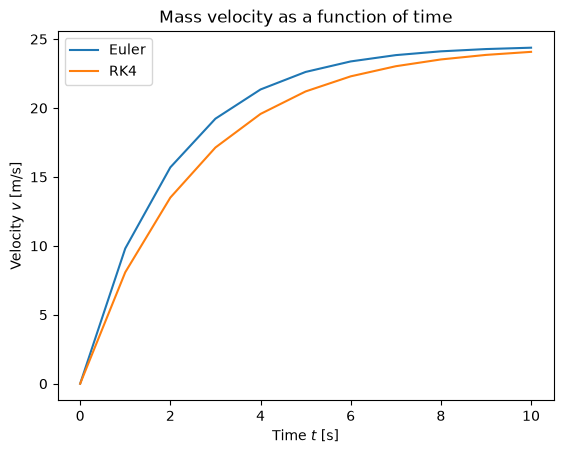

In [19]:
plt.plot(t, y_euler, label='Euler')
plt.plot(t, y_rk4, label='RK4')
plt.title('Mass velocity as a function of time')
plt.xlabel('Time $t$ [s]')
plt.ylabel('Velocity $v$ [m/s]')
plt.legend()
plt.show()

Let us also look at the numerical error:

In [20]:
n=101
t = np.linspace(0, 10, n)
runge_kutta_4_error(f_air_resistance, t, y0=v0, c=0.4)

In [21]:
n=1001
t = np.linspace(0, 10, n)
runge_kutta_4_error(f_air_resistance, t, y0=v0, c=0.4)

When the step is reduced to a tenth, the error decreased by about $10^4$ times (which matches the expectation for a fourth-order method).

## Using ``scipy`` to solve ordinary differential equations

The `scipy` package has [many numerical methods](https://docs.scipy.org/doc/scipy/reference/integrate.html#solving-initial-value-problems-for-ode-systems) implemented for solving initial value problems of ordinary differential equations. Here we will look at the function `scipy.integrate.solve_ivp`, which is suitable for most initial value problems.

### `scipy.integrate.solve_ivp`

Syntax for use (IVP - Initial Value Problem):
```python
scipy.integrate.solve_ivp(fun, t_span, y0, method='RK45',
                          t_eval=None, dense_output=False,
                          events=None, vectorized=False,
                          args=None, **options)
```


An explanation of all the arguments is in the [documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html#scipy-integrate-solve-ivp); here we will highlight a few:

* `fun` is the right-hand side (`func(t, y...)`),
* `t_span` a tuple (`t0`, `tf`) defining the initial time `t0` and final time `tf`,
* `y0` a **list** of initial value(s),
* `method` defines the numerical method (the default is the explicit 'RK45'; for stiff systems the following are better: 'Radau', 'BDF', 'LSODA'),
* `t_eval` is used if we want the solution at specific values of the independent variable,
* `dense_output` whether a continuous solution is also prepared, default `False`,
* `events` for tracking events that stop solving the initial value problem (e.g., when the mass touches the ground and the relative distance to the ground is zero).
* `args` for passing arguments into the function `fun` (see the example below).

The result of calling `solve_ivp` is an object with attributes (selected):

* `t` the values of the independent variable at which the result is computed,
* `y` the result,
* `sol` the continuous-solution function (only in the case of `dense_output=True`)
* `success` is `True` if the solution was computed successfully or terminated due to an event (`events`).

#### Numerical example

Let us define the initial condition and the time vector where we want the result (we show only the first ten elements):

In [22]:
v0 = 0
t = np.linspace(0, 10, 101)
t[:10]

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

We pass the arguments (`g=9.81, m=1., c=0.4`) into the function via the `args` parameter:

In [23]:
from scipy.integrate import solve_ivp
y_ivp = solve_ivp(f_air_resistance, t_span=(t[0], t[-1]), y0=[v0], args=(9.81, 1, 0.4))

We could also use a `lambda` expression ([documentation](https://docs.python.org/tutorial/controlflow.html#lambda-expressions)):
```python
y_ivp = solve_ivp(lambda t,y: f_air_resistance(t, y, c=0.4), t_span=(t[0], t[-1]), y0=[v0])
```

The `lambda` expression used above, `lambda t, y: f_air_resistance(t, y, c=0.4)`, is equivalent to:

```python
def function_name(t, y):
    return f_air_resistance(t, y, c=0.4)
```

Let us look at the result:

In [24]:
y_ivp

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  1.000e-04  1.100e-03  1.110e-02  1.111e-01
             1.111e+00  2.982e+00  5.236e+00  7.948e+00  1.000e+01]
        y: [[ 0.000e+00  9.810e-04  1.079e-02  1.086e-01  1.066e+00
              8.800e+00  1.708e+01  2.150e+01  2.350e+01  2.407e+01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 56
     njev: 0
      nlu: 0

Because `solve_ivp` is already set up for a system of first-order ordinary differential equations, the result is given in two dimensions. The sought result is therefore: `y_ivp.y[0]`.

For comparison, here is also the result with our own fourth-order Runge–Kutta implementation:

In [25]:
y_rk4 = runge_kutta_4(f_air_resistance, t, y0=v0, c=0.4)

In [26]:
y_rk4[:10]

array([0.        , 0.96163898, 1.88557156, 2.77327623, 3.6261735 ,
       4.44562819, 5.23295161, 5.98940363, 6.71619474, 7.41448797])

We plot the result:

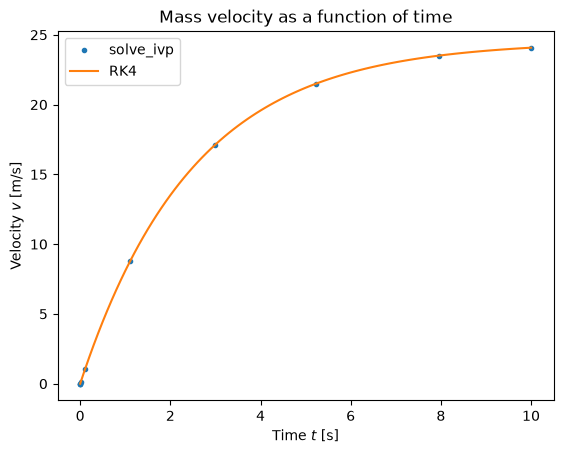

In [27]:
plt.plot(y_ivp.t, y_ivp.y[0], '.', label='solve_ivp')
plt.plot(t, y_rk4, label='RK4')
plt.title('Mass velocity as a function of time')
plt.xlabel('Time $t$ [s]')
plt.ylabel('Velocity $v$ [m/s]')
plt.legend()
plt.show()

## System of ordinary differential equations

Above we looked at solving the initial value problem of a single ordinary differential equation; now we will generalize the solving to an *initial value problem for a system of $m$ first-order ordinary differential equations*.

Such a system is written as:

$$\mathbf{y}'=\mathbf{f}(t, \mathbf{y}),$$

where additional (initial) conditions are given:

$$\mathbf{y}(t_0)=\mathbf{y}_0.$$

By $t$ we denote the independent variable (it need not always be time) and by $\mathbf{f}$ the vector of right-hand sides.

We compute the solution of a system of $m$ differential equations $\mathbf{y}'=\mathbf{f}(t, \mathbf{y})$ at $a=t_0, t_1,\dots,t_{n-1}=b$, that is $m$ function values at each step $y_k(t_i)$, $k=0,1,\dots,m-1$ and $i=0,1,\dots,n-1$. It can be proved that any method we derived for first-order differential equations can also be used for a system of first-order ordinary differential equations if we replace the scalar quantities with the corresponding vector ones.

### Numerical implementation

The Euler and fourth-order Runge–Kutta methods need only minor adjustments (`y0` is a numerical array, `f` returns a list of derivative values):

In [28]:
def euler_system(f, t, y0, *args, **kwargs):
    """
    Euler's method for solving a system of first-order ordinary differential equations: y' = f(t, y)

    :param f:  function called with the parameters t and y, returning a list
               of right-hand-side functions
    :param t:  equidistant (time) vector of the independent variable
    :param y0: list of initial values
    :param args: additional arguments of the function f (positional)
    :param kwargs: additional arguments of the function f (keyword)
    :return y: returns an np.array ``y`` of function values.
    """
    y = np.zeros((t.shape[0], len(y0)))
    y[0] = np.copy(y0)
    h = t[1]-t[0]
    for i, ti in enumerate(t[:-1]):
        # here is the essence of Euler's method
        y[i+1] = y[i]+f(ti, y[i], *args, **kwargs)*h
    return y

In [29]:
def runge_kutta_4_system(f, t, y0, *args, **kwargs):
    """
    Fourth-order Runge–Kutta method for solving a system of first-order ordinary differential equations: y' = f(t, y)

    :param f:  function called with the parameters t and y, returning a list
               of right-hand-side functions
    :param t:  equidistant (time) vector of the independent variable
    :param y0: list of initial values
    :param args: additional arguments of the function f (positional)
    :param kwargs: additional arguments of the function f (keyword)
    :return y: returns an np.array ``y`` of function values.
    """
    def RK4(f, t, y, *args, **kwargs):
        k0 = h*f(t, y, *args, **kwargs)
        k1 = h*f(t + h/2.0, y + k0/2.0, *args, **kwargs)
        k2 = h*f(t + h/2.0, y + k1/2.0, *args, **kwargs)
        k3 = h*f(t + h, y + k2, *args, **kwargs)
        return (k0 + 2.0*k1 + 2.0*k2 + k3)/6.0

    y = np.zeros((t.shape[0], len(y0)))
    y[0] = np.copy(y0)
    h = t[1]-t[0]

    for i, ti in enumerate(t[:-1]):
        y[i+1] = y[i] + RK4(f, ti, y[i], *args, **kwargs)

    return y

#### Numerical example

We extend the falling mass to planar motion; let the magnitude of the air-resistance force be defined as:

$$|\mathbf{F}(\mathbf{v})|=c\,|\mathbf{v}|^2.$$

The air-resistance force acts in the opposite direction to the velocity vector.
![Falling body coupled](./fig/padanje_telesa_vezano.png)

With the help of the figure, we define the force in the $x$ direction:

$$F_x=-c\,\left(v_x^2+v_y^2\right)\,\cos(\alpha)=-c\,\left(v_x^2+v_y^2\right)\,\frac{v_x}{\sqrt{v_x^2+v_y^2}}=-c\,v_x\,\sqrt{v_x^2+v_y^2}.$$

Similarly, the force in the $y$ direction is:

$$F_y=-c\,v_y\,\sqrt{v_x^2+v_y^2}.$$

According to Newton's second law, we write a system of two (coupled) first-order differential equations:

$$F_x=m\,v_x',$$

$$m\,g+F_y=m\,v_y',$$

$m$ is the mass, $g$ the gravitational acceleration, $c$ the air-resistance coefficient, and $v_x$ and $v_y$ the velocities in the $x$ and $y$ directions, respectively. We would like to solve the differential equation subject to the initial condition:

$$v_x(0)=v_y(0)=5\,\textrm{m/s}.$$

Let us define the list of right-hand sides:

In [30]:
def f_air_resistance_force(t, y,  g=9.81, m=1., c=0.5):
    vx, vy = y
    return np.array([-c*vx*np.sqrt(vx**2+vy**2)/m, g-c*vy*np.sqrt(vx**2+vy**2)/m])

Let us define the initial condition and the time vector where we want the result:

In [31]:
y0 = np.array([5., 5.])
t = np.linspace(0, 5, 101)
t[:5]

array([0.  , 0.05, 0.1 , 0.15, 0.2 ])

For comparison, let us compute the solution with the `runge_kutta_4` and `solve_ivp` functions:

In [32]:
y_RK4 = runge_kutta_4_system(f_air_resistance_force, t=t, y0=y0)
y_ivp = solve_ivp(f_air_resistance_force, t_span=(t[0], t[-1]), y0=y0, t_eval=t)

Let us look at the result:

In [33]:
y_ivp.y[:,:5]

array([[5.        , 4.23209907, 3.63858619, 3.16619484, 2.78087608],
       [5.        , 4.68459713, 4.48359747, 4.35932897, 4.28742151]])

In [34]:
y_RK4[:5].T

array([[5.        , 4.23211316, 3.6399137 , 3.16660748, 2.77780226],
       [5.        , 4.68462761, 4.48494405, 4.35999931, 4.28466858]])

We plot the result:

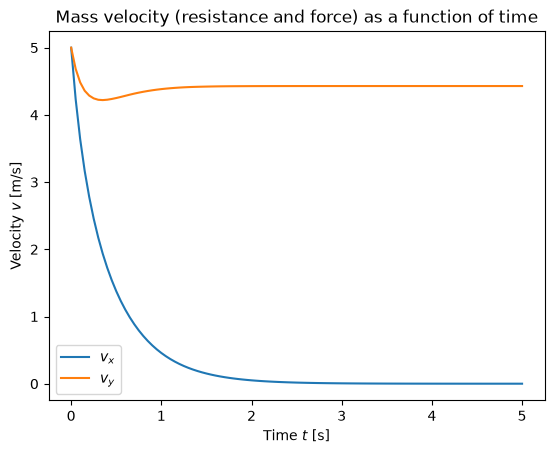

In [35]:
plt.plot(t, y_ivp.y[0], label='$v_x$')
plt.plot(t, y_ivp.y[1], label='$v_y$')
plt.title('Mass velocity (resistance and force) as a function of time')
plt.xlabel('Time $t$ [s]')
plt.ylabel('Velocity $v$ [m/s]')
plt.legend()
plt.show()

### Reformulating a higher-order differential equation into a system of first-order differential equations

We will look at how an ordinary differential equation of arbitrary order $n$:

$$y^{(n)}=f(t, y, y', y'',\dots,y^{(n-1)}),$$

with initial conditions:

$$y(t_0)=k_0,\quad y'(t_0)=k_1,\quad\dots\quad y^{(n-1)}(t_0)=k_{n-1}$$

is reformulated into a system of first-order differential equations.

First, instead of derivatives we introduce new variables:

$$y_i=y^{(i)}, \qquad i=0,1,\dots,n-1.$$

The $n$th-order differential equation written with the new variables is:

$$y_{n-1}'=f(t, y_0, y_1, y_2,\dots,y_{n-1}).$$

We differentiate the new functions with respect to the independent variable:

$$y_i'=y^{(i+1)}=y_{i+1}, \qquad i=0,1,\dots,n-2$$

and

$$y_{n-1}'=f(t, y_0, y_1, y_2,\dots,y_{n-1}).$$

We have obtained a system of first-order ordinary differential equations:

$$
\begin{array}{rcl}
y_0'&=&y_1\\
y_1'&=&y_2\\
&\dots\\
y_{n-1}'&=&f(t, y_0, y_1, y_2,\dots,y_{n-1})\\
\end{array}
$$

with initial conditions:

$$y_0(t_0)=k_0,\quad y_1(t_0)=k_1,\quad\dots\quad y_{(n-1)}(t_0)=k_{n-1}.$$

#### Numerical example

We return to the falling mass:
![Beam](./fig/padanje_telesa_vezano.png)

But this time let us write Newton's second law in terms of displacement (a second-order differential equation):

$$F_x=m\,x'',$$

$$m\,g+F_y=m\,y'',$$

$m$ is the mass, $g$ the gravitational acceleration, $c$ the air-resistance coefficient, and $x''$ and $y''$ the acceleration in the chosen coordinate system. Initial conditions:

$$x(0)=y(0)=0\,\textrm{m}\qquad\textrm{and}\qquad x'(0)= y'(0)=5\,\textrm{m/s}.$$

We have a system of two second-order differential equations. By introducing new variables $y_i$:

$$y_0= x,\quad y_1= x',\quad y_2= y,\quad y_3= y'.$$

We prepare the system of first-order differential equations:

$$
\begin{array}{rcl}
y_0'&=&y_1\\
y_1'&=&F_x/m\\
y_2'&=&y_3\\
y_3'&=&g+F_y/m
\end{array}
$$

Let us define the Python function of right-hand sides / first derivatives:

In [36]:
def f_air_resistance_coupled(t, y, g=9.81, m=1., c=0.5):
    x, vx, y, vy = y
    return np.array([vx, -c*vx*np.sqrt(vx**2+vy**2)/m, vy, g-c*vy*np.sqrt(vx**2+vy**2)/m])

Let us define the initial condition and the time vector where we want the result:

In [37]:
y0 = np.array([0., 5., 0., 5.])
t = np.linspace(0, 5, 101)
t[:5]

array([0.  , 0.05, 0.1 , 0.15, 0.2 ])

We compute the solution:

In [38]:
y_ivp = solve_ivp(f_air_resistance_coupled, t_span=(t[0], t[-1]), y0=y0, t_eval=t)

Let us look at the result ($[x, x', y, y']$):

In [39]:
y_ivp.y[:,:5]

array([[0.        , 0.22992477, 0.42611996, 0.59587483, 0.74424286],
       [5.        , 4.23183658, 3.64002431, 3.16703014, 2.77775353],
       [0.        , 0.24153615, 0.47038377, 0.69124852, 0.9072755 ],
       [5.        , 4.68435696, 4.48497294, 4.36034218, 4.28444004]])

We plot the results; first the velocity, then the position (the $y$ coordinate is positive downward)!

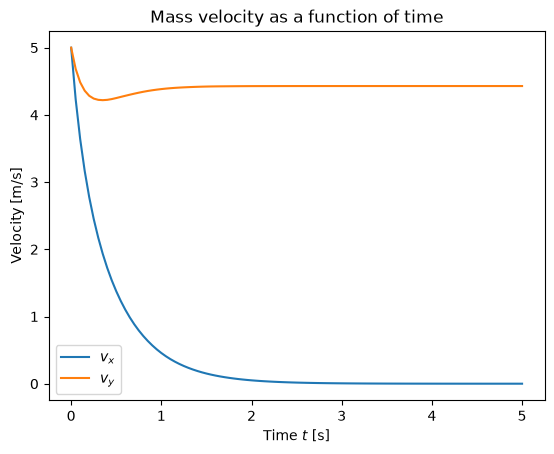

In [40]:
plt.plot(t, y_ivp.y[1], label='$v_x$')
plt.plot(t, y_ivp.y[3], label='$v_y$')
plt.title('Mass velocity as a function of time')
plt.xlabel('Time $t$ [s]')
plt.ylabel('Velocity [m/s]')
plt.legend()
plt.show()

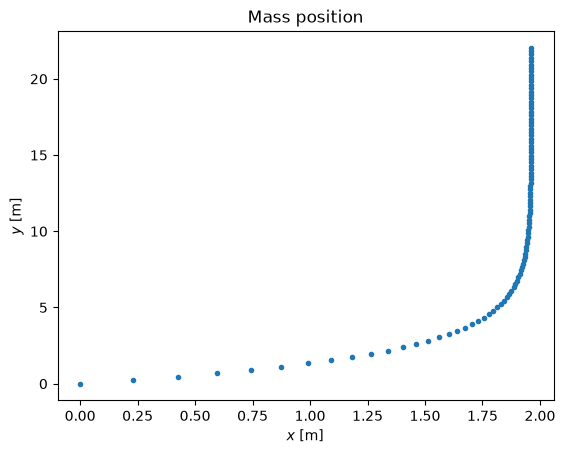

In [41]:
plt.scatter(y_ivp.y[0], y_ivp.y[2], marker='.')
plt.xlabel('$x$ [m]')
plt.ylabel('$y$ [m]')
plt.title('Mass position')
plt.show()

## Stability of solving differential equations*

The numerical solution of differential equations is subject to *method error* and *round-off error*. These errors differ for different numerical methods.

Solving a differential equation is **stable** if a small change in the initial condition leads to a small change in the computed solution; otherwise we speak of **instability of the solution**.

Stability depends on the differential equation, on the numerical method used, and on the integration step $h$.

### Example of a simple oscillator

Let us first look at an example of solving the differential equation of a simple oscillator.
![Oscillator figure](./fig/Slavic-slika-3.6.png)

The figure (source: Slavič, Dinamika, mehanska nihanja in mehanika tekočin, 2017) shows a dynamic system (mass $m$, stiffness $k$) whose differential equation is

$$m\, x'' + k\,x=0.$$

We reformulate this differential equation into the standard form of free vibration:

$$x'' + \omega_0^2\,x=0,$$

where the natural angular frequency is:

$$\omega_0=\sqrt{\frac{k}{m}}$$

and we expect a response of the form:

$$x(t)=A\,\cos(\omega_0\,t)+B\,\sin(\omega_0\,t).$$

If the initial conditions are:

$$x(0\,\textrm{s})=x_0\qquad\textrm{and}\qquad x'(0\,\textrm{s})=0\,\textrm{m/s},$$

the solution of the initial value problem is:

$$x(t)=x_0\,\cos(\omega_0\,t).$$

#### Numerical example

First let us define the vector of initial conditions and the function of right-hand sides / first derivatives (we convert the second-order differential equation into a system of first-order differential equations $\mathbf{y}'=\mathbf{f}(t, \mathbf{y})$), where $y_0=x, y_1=x'$:

In [42]:
def f_oscillator(t, y, omega0=2*np.pi):
    """
    Right-hand-side function for an oscillator with one degree of freedom

    :param t: time
    :param y: list of initial values
    :param omega: natural angular frequency
    :return y': list of derivative values
    """
    return np.array([y[1], -omega0**2*y[0]])

Let us define the data and the analytical solution:

In [43]:
x0 = 1.
omega0 = 2*np.pi
x_initial_conditions = np.array([x0, 0.])
t1 = 4.
time = np.linspace(0, t1, 500)
displacement = x0*np.cos(omega0*time) # analytical solution
velocity = -x0*omega0*np.sin(omega0*time) # analytical solution

Solution using the Euler and fourth-order Runge–Kutta methods:

In [44]:
t_Eu = np.linspace(0, t1, 101)
t_RK4 = t_Eu
dt = t_Eu[1]

x_Eu = euler_system(f_oscillator, t_Eu, x_initial_conditions)
x_RK4 = solve_ivp(f_oscillator, t_span=(t_RK4[0], t_RK4[-1]), y0=x_initial_conditions, t_eval=t_RK4).y

Let us plot the results:

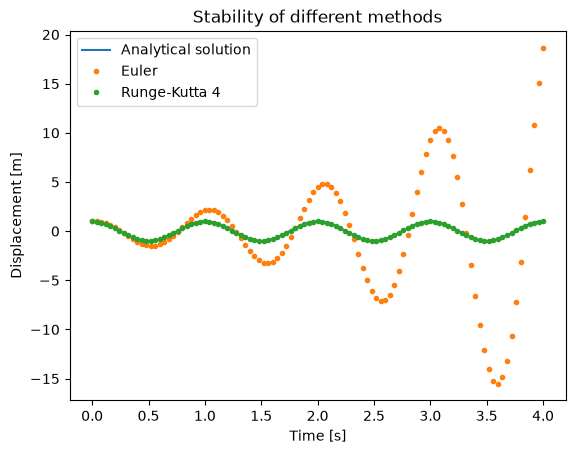

In [45]:
plt.plot(time, displacement, label='Analytical solution')
plt.plot(t_Eu, x_Eu[:,0], '.', label='Euler')
plt.plot(t_RK4, x_RK4[0], '.', label='Runge-Kutta 4')
plt.legend()
plt.title('Stability of different methods')
plt.ylabel('Displacement [m]')
plt.xlabel('Time [s]')
plt.show()

We observe that Euler's method is unstable, and if we increased the step, the fourth-order Runge–Kutta method would also become unstable.

#### Why is Euler's method so unstable?

In [46]:
x_Eu[:10,0]

array([ 1.        ,  1.        ,  0.93683453,  0.8105036 ,  0.62499707,
        0.3882947 ,  0.1121141 , -0.18859332, -0.49638247, -0.79225904])

Let us recall Euler's method:

$$x(t+h)=x(t)+x'(t)\,h,$$

which tells us that we determine the displacement $x(t+h)$ from the position $x(t)$ and the velocity $x'(t)$. The initial conditions stem from the maximum deflection $x(t=0)=1$, and at that point the velocity is $x'(t=0)=0$, which means that $x(t+h)=1$. Already in the first step we therefore make a relatively large error. But why does the value then start to grow in an alternating fashion?

Recall that the analytical solution is $x(t)=x_0\,\cos(\omega_0\,t)$, and therefore $x'(t)=-\omega_0\,x_0\,\sin(\omega_0\,t)$.

We substitute the prepared expressions into Euler's method and rearrange:

$$x(t+h)=x(t)+x'(t)\,h=x_0\,\left(\cos(\omega_0\,t)-\omega_0\,h\,\sin(\omega_0\,t)\right).$$

Assume we look at the state at a time $t=\pi/(2\omega_0)$, when $\cos(\omega_0\,t)=0$ and $\sin(\omega_0\,t)=1$:

$$x(t+h)=x_0\,\underbrace{\left(-\omega_0\,h\right)}_{A}.$$

If the absolute value of the expression $A$ is greater than 1, then at time $t+h$ the value will be greater than in the previous step, and probably again in the next one. It follows that instability can occur. To avoid it, the following must hold:

$$|A|<1\qquad\rightarrow\qquad h<\frac{1}{\omega_0}.$$

Note: in some books you will also see the value $h<2/\omega_0$; a unique bound for all differential equations cannot be defined; in general, however, the step is defined relative to the shortest period $T$ in the differential equation (e.g.: $h<2/\omega_0$ is essentially the same as $h<2/(2\pi/T)$, i.e., $h<T/\pi$). The period $T$ is defined relative to the highest natural frequency of the system $T=1/f_{\textrm{max}}$, which we compute from the eigenvalue of the system.

# Additional: Example of the Van der Pol oscillator

The purpose of this example is to show how the choice of integrator can affect the speed of solving a problem! The Van der Pol oscillator is described [here](http://en.wikipedia.org/wiki/Van_der_Pol_oscillator).

Let us define the list of derivatives:

In [47]:
def f_van_der_pol(t, y, mu=1000):
    """
    Right-hand-side function for the Van der Pol oscillator

    :param t: time
    :param y: list of initial values
    :param mu: damping and nonlinearity parameter
    :return y': list of derivative values
    """
    return np.array([y[1], mu*(1-y[0]**2)*y[1]-y[0]])

In [48]:
x_initial_conditions = np.array([1.5, 0.])
dt = 0.1
t1 = 3000

Solution using the RK45 method (this is an explicit scheme, which is not suitable for stiff systems of differential equations; solving is very slow, so we compute the solution only up to `t1/100`):

In [49]:
vp_RK45 = solve_ivp(f_van_der_pol, t_span=(0., t1/100), y0=x_initial_conditions, method='RK45')

The implicit BDF scheme (Backward Differentiation Formulas) turns out here to be much more suitable. Because of its stability, the steps can be much larger and therefore the solving is much faster:

In [50]:
vp_BDF = solve_ivp(f_van_der_pol, t_span=(0., t1), y0=x_initial_conditions, method='BDF')

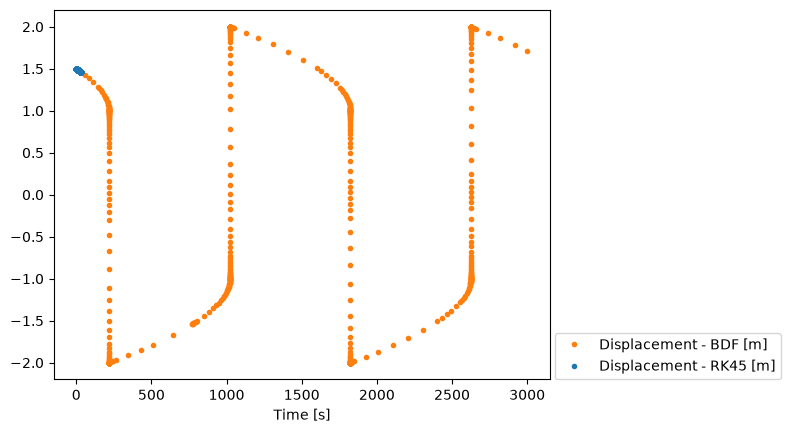

In [51]:
plt.plot(vp_BDF.t, vp_BDF.y[0], 'C1.', label='Displacement - BDF [m]')
plt.plot(vp_RK45.t, vp_RK45.y[0], 'C0.', label='Displacement - RK45 [m]')
plt.xlabel('Time [s]')
plt.legend(loc=(1.01, 0));

# Additional: symbolic solving of a second-order differential equation

We will look at the example shown in the figure, where a mass $m$ is on an incline of slope $\alpha$. The coefficient of friction is $\mu$, and the gravitational acceleration is $g$. The initial velocity is $\dot y(0\,\textrm{s})=v_0$, the displacement $y(0\,\textrm{s})=0\,\textrm{m}$.
![Mass on an incline](./fig/masa_na_klancu.png)
The equation of motion (only for the $y$ direction) is defined according to Newton's second law (see the free-body force diagram).

#### Derivation of the equation of motion

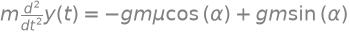

In [52]:
y = sym.Function('y')
m, mu, g, alpha, t, v0 = sym.symbols('m, mu, g, alpha, t, v0')
eq = sym.Eq(m*y(t).diff(t,2),  m*g*sym.sin(alpha)-m*g*sym.cos(alpha)*mu)
eq

The solution of the equation is:

In [53]:
dsol = sym.dsolve(eq, y(t))
dsol

To determine $C_1$ and $C_2$, we substitute $t=0\,\textrm{s}$:

In [54]:
dsol.args[1].subs(t, 0)

Then we differentiate with respect to time and again substitute $t=0\,\textrm{s}$:

In [55]:
dsol.args[1].diff(t).subs(t, 0)

Based on the initial conditions, we have therefore determined the constants:

In [56]:
initial_conditions = {'C1': 0, 'C2': v0}

The solution follows:

In [57]:
solution = dsol.args[1].subs(initial_conditions)
solution

Let us prepare functions for the numerical call:

In [58]:
data = {mu: 0.3, alpha: 15*np.pi/180, v0: 1., g: 9.81} # here we use np.pi so that we have a numerical value

displacement = sym.lambdify(t, solution.subs(data), 'numpy')
velocity = sym.lambdify(t, solution.diff(t).subs(data), 'numpy')

print('Displacement at 0s: {:g}m'.format(displacement(0)))
print('Velocity at 0s: {:g}m/s'.format(velocity(0)))

Displacement at 0s: 0m
Velocity at 0s: 1m/s


Let us prepare the plot:

In [59]:
time = np.linspace(0, 4, 100)
time2 = np.linspace(0, 4, 5)

In [60]:
def figure():
    plt.plot(time, displacement(time), 'C0', label='Displacement [m]')
    plt.plot(time, velocity(time), 'C1', label='Velocity [m/s]')
    plt.plot(time2, displacement(time2), 'C0o', label='Displacement - large step [m]')
    plt.plot(time2, velocity(time2), 'C1o', label='Velocity - large step [m/s]')
    plt.xlabel('Time [s]')
    plt.ylabel('Displacement [m] / Velocity [m/s]')
    plt.legend(loc=(1.01, 0));
    plt.show()

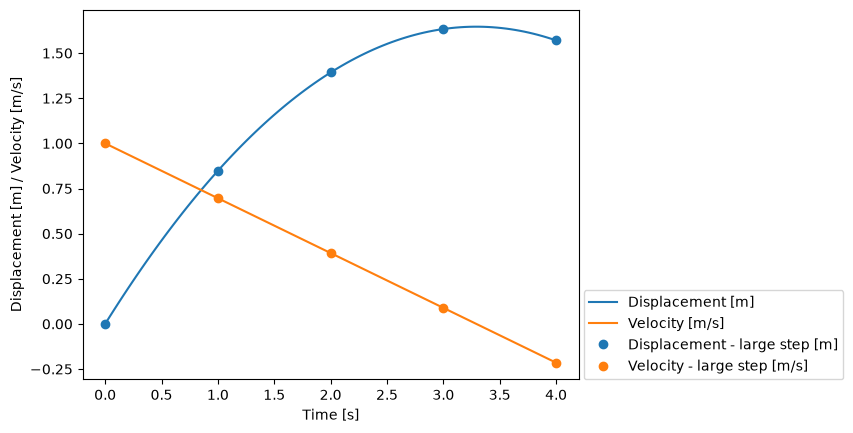

In [61]:
figure()

#### Symbolic reformulation of the differential equation into a system of first-order differential equations

Let us recall the original differential equation:

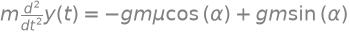

In [62]:
eq

Let us define new variables and prepare the function $f$:

In [63]:
y0 = sym.Function('y0')
y1 = sym.Function('y1')
f = sym.simplify(eq.args[1]/m)
f

Now let us connect the new variables.

Let $d y_0/dt$ be equal to $y_1$:

In [64]:
eq1 = sym.Eq(y0(t).diff(t), y1(t))
eq1

Let the derivative $d y_1/dt$ (which is essentially $y''$) be equal to the function $f$:

In [65]:
eq2 = sym.Eq(y1(t).diff(t), f)
eq2

We write the expressions above in vector form:

$$\mathbf{y}'=\mathbf{f}(t, \mathbf{y}).$$

In [66]:
y_derivative = [y0(t).diff(t), y1(t).diff(t)]
y_derivative

In [67]:
f_vec = [y1(t), f]
f_vec

Let us now recall ``f_vec``:

In [68]:
f_vec

If we solve numerically, then we write the function $\mathbf{f}(t, \mathbf{y})$ as:

In [69]:
acceleration = float((eq.args[1]/m).simplify().subs(data))
acceleration # investigate why we defined it this way here! hint: type(acceleration)

In [70]:
def F_block(t, y):
    return np.array([y[1], acceleration],dtype=float)

Let us check the function at the initial time $t=0\,$s and at the initial conditions $[y_0, y_1]=[0, v_0]$:

In [71]:
y_initial_conditions = np.array([0, data[v0]])
y_initial_conditions

array([0., 1.])

In [72]:
F_block(0., y_initial_conditions)

array([ 1.        , -0.30370487])

Now let us use Euler's method:

In [73]:
#%%timeit
x_Eu = np.linspace(0, 4, 5)
y_Eu = euler_system(F_block, x_Eu, np.array([0, 1.]))
y_Eu

array([[ 0.        ,  1.        ],
       [ 1.        ,  0.69629513],
       [ 1.69629513,  0.39259025],
       [ 2.08888538,  0.08888538],
       [ 2.17777075, -0.2148195 ]])

We plot and compare with the analytical solution:

In [74]:
def plot_euler(n=5):
    x_Eu = np.linspace(0, 4, n)
    y_Eu = euler_system(F_block, x_Eu, np.array([0, 1.]))
    plt.title('Euler\'s method with step $h={:g}$'.format(x_Eu[1]-x_Eu[0]))
    plt.plot(time, displacement(time), 'C0', label='Displacement - analytical [m]')
    plt.plot(time, velocity(time), 'C1', label='Velocity - analytical [m/s]')
    plt.plot(x_Eu, y_Eu[:, 0], 'C0.', label='Displacement - Euler [m]')
    plt.plot(x_Eu, y_Eu[:, 1], 'C1.', label='Velocity - Euler [m/s]')
    plt.xlabel('Time [s]')
    plt.ylabel('Displacement [m] / Velocity [m/s]')
    plt.ylim(-0.5, 2.5)
    plt.legend(loc=(1.01, 0))
    plt.show();

In [75]:
interact(plot_euler, n=(3, 10, 1));

interactive(children=(IntSlider(value=5, description='n', max=10, min=3), Output()), _dom_classes=('widget-int…

---

# Exercise questions

---

**Question 1**: Solve the differential equation:

$$y' - y = \sin(x)$$

symbolically using the ``sympy`` module. Plot the solution on the interval $x\in [0, 5]$ (hint: $y = y(x)$). The values of the unknowns are positive and real.

Initial condition: $y(x = 0) = 0$

---

## Euler's method

**Question 2**: Solve the differential equation:

$$y' - y = \sin(x)$$

also numerically with the provided Euler's method function for 30 values on the interval $x \in [0, 5]$.

Initial condition: $y(x = 0) = 0$

**Question 3:** Plot the values of the error of the numerical solution with Euler's method as you increase the number of discrete points on the interval $x \in [0, 5]$ from 10 to 100 with a step of 30.

---

## Solving higher-order ODEs

**Question 4**: A skydiver of mass $m$ is subjected to gravity and the air-resistance force. The skydiver's motion is described by the differential equation:

$$\ddot{y} = g - \frac{C_D}{m}\dot{y}^2$$

Write the system of first-order differential equations and prepare a function for numerical solving. Compute the values of the first-derivative function at the initial time and the initial conditions.

Data:
* $g = 9.81 \text{m/s}^2$
* $C_D = 0.203 \text{kg/m}$
* $m = 80 \text{kg}$
* $y(0) = \dot{y}(0) = 0$

------

**Question 5:** Use the function prepared above to numerically solve the skydiver's differential equation with the function ``scipy.integrate.solve_ivp`` at 100 discrete points for the first 30 seconds of the fall.

Plot the resulting path ($y$) and velocity of the skydiver as a function of time $t$. How would you also compute the acceleration?

**Question 6**: A projectile of mass $m$ is launched with velocity $v_0$ at an angle $\alpha$. The equations of motion for the displacements in the $x$ and $y$ directions are:

$$\ddot{x}(t) = - F~\frac{\text{cos}(\alpha)}{m} \qquad \ddot{y}(t) = -F~\frac{~\text{sin}(\alpha)}{m} - g$$


The drag force $F$ equals $F = c~v^{3/2}$, where the velocity is $v = \sqrt{\dot{x}^2 + \dot{y}^2}$ and $\alpha = \arctan{\Big(\frac{\dot{y}}{\dot{x}}\Big)}$

<img src="fig/vaje/izstrelek.png" width=300>
<center><font size="1.5">source: Numerical Methods in Engineering With Python 3, 3rd Ed, Jaan Kiusalaas</font></center>

Write the system of two second-order differential equations in the form of a system of four first-order differential equations and determine the vector of initial conditions.

Data:
* $\alpha_0 = \pi/3 ~ \text{rad}$
* $v_0 = 32 ~ \text{m/s}$
* $g = 9.81 ~ \text{m/s}^2$
* $c = 0.029 ~ \text{kg}/(\text{ms}^2)$
* $m = 0.41 ~ \text{kg}$

**Question 7:** Prepare the derivative function for numerically solving the above system of two second-order differential equations and, using ``scipy.integrate.solve_ivp``, determine the projectile's flight curve at 100 discrete points over the time $t \in [0, 5]$ s.

$$\ddot{x}(t) = - F~\frac{\cos(\alpha)}{m} \qquad \ddot{y}(t) = -F~\frac{\sin(\alpha)}{m} - g$$

The drag force $F$ equals $F = c~v^{3/2}$, where the velocity is $v = \sqrt{\dot{x}^2 + \dot{y}^2}$ and $\alpha = \arctan{\Big(\frac{\dot{y}}{\dot{x}}\Big)}$

**Question 8:** Solve the given system of two second-order differential equations also using the function ``scipy.integrate.solve_ivp`` with the ``'LSODA'`` method.

Integrate the system of equations until the time when the projectile falls to the ground ($y = 0$). Use the same initial conditions as in the previous problem and a maximum spacing on the time axis of $\Delta t = 0.1$ s.

Plot the obtained trajectory of the projectile's flight graphically.